Импорт библиотек для обработки данных, векторизации текста, кластеризации, визуализации

In [1]:
import re
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import hdbscan
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


Чтение 20 строк Android-лога для ознакомления с форматом

In [2]:
with open('/kaggle/input/datasets/omduggineni/loghub-android-log-data/Android.log','r',encoding='utf-8', errors='ignore') as f:
    for _ in range(20):
        print(f.readline().strip())

12-17 19:31:36.263  1795  1825 I PowerManager_screenOn: DisplayPowerStatesetColorFadeLevel: level=1.0
12-17 19:31:36.263  5224  5283 I SendBroadcastPermission: action:android.com.huawei.bone.NOTIFY_SPORT_DATA, mPermissionType:0
12-17 19:31:36.264  1795  1825 D DisplayPowerController: Animating brightness: target=21, rate=40
12-17 19:31:36.264  1795  1825 I PowerManager_screenOn: DisplayPowerController updatePowerState mPendingRequestLocked=policy=BRIGHT, useProximitySensor=true, useProximitySensorbyPhone=true, screenBrightness=33, screenAutoBrightnessAdjustment=0.0, brightnessSetByUser=true, useAutoBrightness=true, blockScreenOn=false, lowPowerMode=false, boostScreenBrightness=false, dozeScreenBrightness=-1, dozeScreenState=UNKNOWN, useTwilight=false, useSmartBacklight=true, brightnessWaitMode=false, brightnessWaitRet=true, screenAutoBrightness=-1, userId=0
12-17 19:31:36.264  1795  2750 I PowerManager_screenOn: DisplayPowerState Updating screen state: state=ON, backlight=823
12-17 19:

Регулярное выражение для извлечения timestamp, PID, TID, уровня, тега и сообщения.
Очистка сообщений от hex-кодов (0x...).
Фильтрация только ошибок, фаталов и предупреждений (уровни E, F, W)

In [3]:
log_pattern = re.compile(r'(\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3})\s+(\d+)\s+(\d+)\s+([VDIWEF])\s+([^:]+):\s+(.*)')
log_data = []

with open("/kaggle/input/datasets/omduggineni/loghub-android-log-data/Android.log", 'r', encoding='utf-8', errors='ignore') as f:
    for line in f:
        if match := log_pattern.match(line.strip()):
            clean_msg = re.sub(r'\b0x[0-9a-fA-F]+\b', ' ', match.group(6))
            log_data.append({
                'timestamp': match.group(1),
                'pid': int(match.group(2)),
                'tid': int(match.group(3)),
                'level': match.group(4),
                'tag': match.group(5),
                'full_message': clean_msg
            })

df = pd.DataFrame(log_data)
df_errors = df[df['level'].isin(['E', 'F', 'W'])].copy()

print(f"Всего записей: {len(df)}")
print(f"Ошибки/предупреждения: {len(df_errors)}")

Всего записей: 1484223
Ошибки/предупреждения: 233742


TF-IDF векторизация сообщений (стоп-слова, биграммы, 5000 признаков).
Снижение размерности до 100 компонент методом SVD.
Вывод суммарной объяснённой дисперсии

In [4]:
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2),
                             max_features=5000, min_df=2, max_df=0.8)

tfidf = vectorizer.fit_transform(df_errors['full_message'].fillna(''))

svd = TruncatedSVD(n_components=100, random_state=42)
reduced = svd.fit_transform(tfidf)

print(f"Размер матрицы после SVD: {reduced.shape}")
print(f"Объяснённая дисперсия (суммарно): {svd.explained_variance_ratio_.sum():.3f}")

Размер матрицы после SVD: (233742, 100)
Объяснённая дисперсия (суммарно): 0.768


Кластеризация на данных после SVD.
Минимальный размер кластера = 30, min_samples = 5.
Вывод распределения по кластерам ( -1 = шум) и количества кластеров

In [5]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=5, metric='euclidean')
labels = clusterer.fit_predict(reduced)
df_errors['cluster'] = labels


cluster_counts = df_errors['cluster'].value_counts().sort_index()
print("Распределение по кластерам ( -1 = шум):\n", cluster_counts)
print(f"\nКоличество шумовых точек: {cluster_counts.get(-1, 0)}")
print(f"Число найденных кластеров: {(cluster_counts.index != -1).sum()}")

Распределение по кластерам ( -1 = шум):
 cluster
-1      7333
 0       792
 1       384
 2       418
 3       384
        ... 
 762      57
 763      47
 764      44
 765      31
 766     885
Name: count, Length: 768, dtype: int64

Количество шумовых точек: 7333
Число найденных кластеров: 767


Вычисление Silhouette Score и Davies–Bouldin Index только для кластеризованных точек (исключая шум)

In [6]:
mask = df_errors['cluster'] != -1
if mask.sum() > 1 and len(set(df_errors.loc[mask, 'cluster'])) > 1:
    sil = silhouette_score(reduced[mask], df_errors.loc[mask, 'cluster'], metric='euclidean')
    db = davies_bouldin_score(reduced[mask], df_errors.loc[mask, 'cluster'])
    print(f"Silhouette Score (только кластеризованные точки): {sil:.4f}")
    print(f"Davies–Bouldin Index: {db:.4f}")
else:
    print("Недостаточно кластеров для вычисления метрик.")

Silhouette Score (только кластеризованные точки): 0.9679
Davies–Bouldin Index: 0.3681


Отбор только не-шумовых точек (cluster != -1)
X – SVD-представления, y – метки кластеров

In [7]:

df_clustered = df_errors[df_errors['cluster'] != -1].copy()
X = reduced[df_errors['cluster'] != -1]
y = df_clustered['cluster'].values

print(f"Размер X: {X.shape}")
print(f"Уникальных кластеров: {len(np.unique(y))}")

Размер X: (226409, 100)
Уникальных кластеров: 767


Разделение на обучающую (80%) и тестовую (20%) выборки.
Обучение Random Forest (100 деревьев, max_depth=15).
Вывод точности и подробного classification_report

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Точность Random Forest на тесте: {acc:.3f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Точность Random Forest на тесте: 0.821

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       158
           1       0.00      0.00      0.00        77
           2       0.00      0.00      0.00        84
           3       0.00      0.00      0.00        77
           4       1.00      1.00      1.00       109
           5       1.00      1.00      1.00      2191
           6       1.00      1.00      1.00       249
           7       0.00      0.00      0.00        77
           8       1.00      1.00      1.00        77
           9       0.05      1.00      0.10       420
          10       1.00      1.00      1.00       227
          11       1.00      1.00      1.00       108
          12       0.00      0.00      0.00        78
          13       1.00      1.00      1.00        78
          14       0.00      0.00      0.00       174
          15       1.00      1.00      1.00        77
          16      

Выбор 10 самых больших кластеров, построение confusion matrix

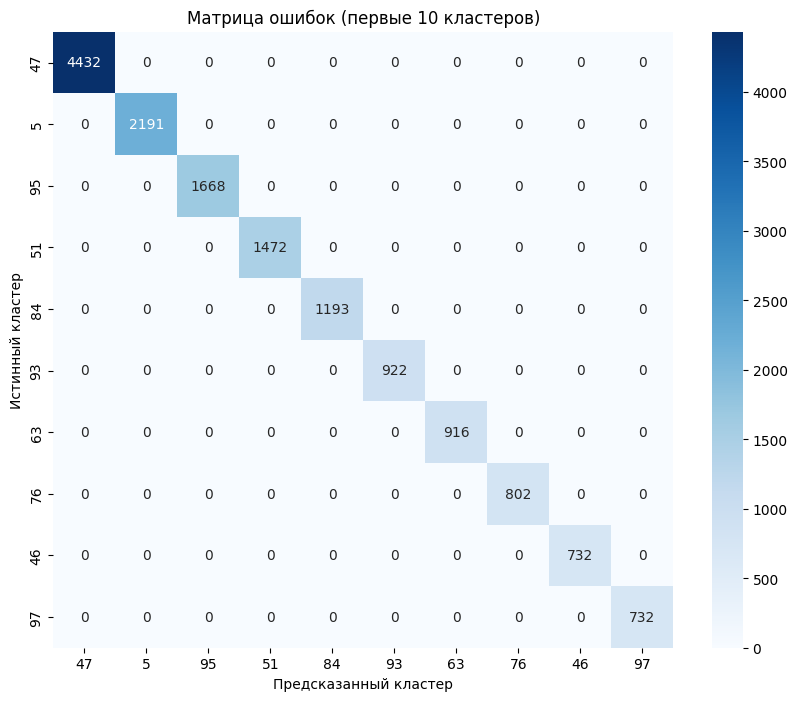

In [9]:
top_clusters = sorted(np.unique(y), key=lambda c: -np.sum(y == c))[:10]


mask = np.isin(y_test, top_clusters) & np.isin(y_pred, top_clusters)

y_test_subset = y_test[mask]
y_pred_subset = y_pred[mask]

cm = confusion_matrix(y_test_subset, y_pred_subset, labels=top_clusters)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_clusters, yticklabels=top_clusters)
plt.title('Матрица ошибок (первые 10 кластеров)')
plt.ylabel('Истинный кластер')
plt.xlabel('Предсказанный кластер')
plt.show()

Для 10 крупнейших кластеров вывод примеров сообщений и наиболее частых тегов

In [10]:
cluster_sizes = df_errors[df_errors['cluster'] != -1]['cluster'].value_counts()
top_clusters_analysis = cluster_sizes.head(10).index

for cl in top_clusters_analysis:
    cl_data = df_errors[df_errors['cluster'] == cl]
    print(f"\n=== Кластер {cl} (размер {len(cl_data)}) ===")
    print("Примеры сообщений:")
    for msg in cl_data['full_message'].value_counts().head(3).index:
        print(f"  - {msg[:120]}")
    print("Частые теги:", cl_data['tag'].value_counts().head(3).to_dict())


=== Кластер 47 (размер 22160) ===
Примеры сообщений:
  - getTempInfo error: null, 0
Частые теги: {'PTM.FileNodeInfo': 22160}

=== Кластер 5 (размер 10955) ===
Примеры сообщений:
  - [HME_JPEG_DEC_Delete](3298): HME_JPEG_DEC_Delete: decoder_ctx=null
Частые теги: {'HW-JPEG-DEC': 10955}

=== Кластер 95 (размер 8339) ===
Примеры сообщений:
  - Cannot call determinedVisibility() - never saw a connection for the pid: 5157
Частые теги: {'cr_BindingManager': 8339}

=== Кластер 51 (размер 7360) ===
Примеры сообщений:
  - begin
  - byod file begin!
  - begin to createBiglogzip!
Частые теги: {'libteec ': 7318, 'AppLogApi': 22, 'SDK     ': 14}

=== Кластер 84 (размер 5967) ===
Примеры сообщений:
  - shouldBlockLocation running ...
  - shouldBlockDataSwitch running ...
Частые теги: {'PhoneInterfaceManager': 5967}

=== Кластер 93 (размер 4608) ===
Примеры сообщений:
  - getRunningAppProcesses: caller 10102 does not hold REAL_GET_TASKS; limiting output
  - getTasks: caller 10102 does not hold REAL_G

Важность SVD-компонент по Random Forest.
Вывод слов с наибольшим весом в первой SVD-компоненте (самой важной)

In [11]:
importances = rf.feature_importances_
important_indices = importances.argsort()[-15:][::-1]
print("Топ-15 важных компонент SVD (по Random Forest):")
for idx in important_indices:
    print(f"  Компонента {idx}: {importances[idx]:.4f}")


print("\nСлова с наибольшим весом в первой SVD-компоненте:")
comp0_weights = svd.components_[0]
top_feat_idx = comp0_weights.argsort()[-10:][::-1]
feature_names = vectorizer.get_feature_names_out()
for idx in top_feat_idx:
    print(f"  {feature_names[idx]}: {comp0_weights[idx]:.4f}")

Топ-15 важных компонент SVD (по Random Forest):
  Компонента 5: 0.0626
  Компонента 1: 0.0577
  Компонента 4: 0.0467
  Компонента 2: 0.0450
  Компонента 3: 0.0432
  Компонента 7: 0.0409
  Компонента 0: 0.0372
  Компонента 9: 0.0338
  Компонента 12: 0.0298
  Компонента 10: 0.0288
  Компонента 13: 0.0288
  Компонента 15: 0.0287
  Компонента 24: 0.0264
  Компонента 11: 0.0243
  Компонента 17: 0.0233

Слова с наибольшим весом в первой SVD-компоненте:
  error null: 0.4648
  gettempinfo: 0.4648
  gettempinfo error: 0.4648
  error: 0.4317
  null: 0.3993
  hme_jpeg_dec_delete: 0.0468
  3298 hme_jpeg_dec_delete: 0.0234
  hme_jpeg_dec_delete 3298: 0.0234
  hme_jpeg_dec_delete decoder_ctx: 0.0234
  decoder_ctx null: 0.0234
